# Lab | Text Generation from Shakespeare's Sonnet

This notebook explores the fascinating domain of text generation using a deep learning model trained on Shakespeare's sonnets. 

The objective is to create a neural network capable of generating text sequences that mimic the style and language of Shakespeare.

By utilizing a Recurrent Neural Network (RNN) with Long Short-Term Memory (LSTM) layers, this project aims to demonstrate how a model can learn and replicate the complex patterns of early modern English. 

The dataset used consists of Shakespeare's sonnets, which are preprocessed and tokenized to serve as input for the model.

Throughout this notebook, you will see the steps taken to prepare the data, build and train the model, and evaluate its performance in generating text. 

This lab provides a hands-on approach to understanding the intricacies of natural language processing (NLP) and the potential of machine learning in creative text generation.

Let's import necessary libraries

In [1]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku 
import numpy as np

Let's get the data!

In [2]:
import requests
url = 'https://raw.githubusercontent.com/martin-gorner/tensorflow-rnn-shakespeare/master/shakespeare/sonnets.txt'
resp = requests.get(url)
with open('sonnets.txt', 'wb') as f:
    f.write(resp.content)

data = open('sonnets.txt').read()

corpus = data.lower().split("\n")

Step 1: Initialise a tokenizer and fit it on the corpus variable using .fit_on_texts

In [3]:
# Initialise the tokenizer
tokenizer = Tokenizer()

# Fit it on the corpus (builds the word -> index vocabulary)
tokenizer.fit_on_texts(corpus)

# Optional: inspect the result
total_words = len(tokenizer.word_index) + 1  # +1 for the reserved 0 index (padding)
print(tokenizer.word_index)
print(total_words)

{'and': 1, 'the': 2, 'to': 3, 'of': 4, 'my': 5, 'i': 6, 'in': 7, 'that': 8, 'thy': 9, 'thou': 10, 'with': 11, 'for': 12, 'is': 13, 'not': 14, 'love': 15, 'but': 16, 'a': 17, 'me': 18, 'thee': 19, 'so': 20, 'be': 21, 'as': 22, 'all': 23, 'you': 24, 'his': 25, 'which': 26, 'when': 27, 'it': 28, 'this': 29, 'by': 30, 'your': 31, 'doth': 32, 'do': 33, 'from': 34, 'on': 35, 'or': 36, 'no': 37, 'then': 38, 'have': 39, 'what': 40, 'are': 41, 'if': 42, 'more': 43, 'mine': 44, 'their': 45, 'shall': 46, 'sweet': 47, 'time': 48, 'will': 49, 'they': 50, 'beauty': 51, 'nor': 52, 'eyes': 53, 'art': 54, 'her': 55, 'heart': 56, 'yet': 57, 'o': 58, 'than': 59, 'can': 60, 'should': 61, 'thine': 62, 'now': 63, 'where': 64, 'make': 65, 'one': 66, 'hath': 67, 'he': 68, 'fair': 69, 'still': 70, 'how': 71, 'eye': 72, 'him': 73, 'like': 74, 'true': 75, 'see': 76, 'am': 77, 'she': 78, 'those': 79, 'though': 80, 'being': 81, 'some': 82, 'every': 83, 'such': 84, 'own': 85, 'were': 86, 'dost': 87, 'who': 88, 'liv

Step 2: Calculate the Vocabulary Size

Let's figure out how many unique words are in your corpus. This will be the size of your vocabulary.

Calculate the length of tokenizer.word_index, add 1 to it and store it in a variable called total_words.

In [4]:
total_words = len(tokenizer.word_index) + 1
print(total_words)

3375


Create an empty list called input_sequences.

For each sentence in your corpus, convert the text into a sequence of integers using the tokenizer.
Then, generate n-gram sequences from these tokens.

Store the result in the list input_sequences.

In [5]:
input_sequences = []

for line in corpus:
    # Convert the sentence into a list of integers
    token_list = tokenizer.texts_to_sequences([line])[0]

    # Build n-gram sequences: [t0, t1], [t0, t1, t2], [t0, t1, t2, t3], ...
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

print(len(input_sequences))
print(input_sequences[:5])

15484
[[3, 2], [3, 2, 313], [3, 2, 313, 1375], [3, 2, 313, 1375, 4], [118, 1376]]


Calculate the length of the longest sequence in input_sequences. Assign the result to a variable called max_sequence_len.

Now pad the sequences using pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre').
Convert it to a numpy array and assign the result back to our variable called input_sequences.

In [6]:
# Length of the longest n-gram sequence
max_sequence_len = max(len(seq) for seq in input_sequences)

# Pad every sequence with zeros at the front so they all share the same length
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)

print(max_sequence_len)
print(input_sequences.shape)
print(input_sequences[:3])

11
(15484, 11)
[[   0    0    0    0    0    0    0    0    0    3    2]
 [   0    0    0    0    0    0    0    0    3    2  313]
 [   0    0    0    0    0    0    0    3    2  313 1375]]


Prepare Predictors and Labels

Split the sequences into two parts:

- Predictors: All elements from input_sequences except the last one.
- Labels: The last element of each sequence in input_sequences.

In [7]:
# Predictors: every token except the last one in each row
predictors = input_sequences[:, :-1]

# Labels: the last token in each row
labels = input_sequences[:, -1]

print(predictors.shape)
print(labels.shape)
print(predictors[0], labels[0])

(15484, 10)
(15484,)
[0 0 0 0 0 0 0 0 0 3] 2


One-Hot Encode the Labels :

Convert the labels (which are integers) into one-hot encoded vectors. 

Ensure the length of these vectors matches the total number of unique words in your vocabulary.

Use ku.to_categorical() on labels with num_classes = total_words

Assign the result back to our variable labels.

In [8]:
labels = ku.to_categorical(labels, num_classes=total_words)

print(labels.shape)
print(labels[0].argmax())

(15484, 3375)
2


# Initialize the Model

Start by creating a Sequential model.

Add Layers to the Model:

Embedding Layer: The first layer is an embedding layer. It converts word indices into dense vectors of fixed size (100 in this case). Set the input length to the maximum sequence length minus one, which corresponds to the number of previous words the model will consider when predicting the next word.

Bidirectional LSTM Layer: Add a Bidirectional LSTM layer with 150 units. This layer allows the model to learn context from both directions (past and future) in the sequence. return_sequences=True

Dropout Layer: Add a dropout layer with a rate of 0.2 to prevent overfitting by randomly setting 20% of the input units to 0 during training.

LSTM Layer: Add a second LSTM layer with 100 units. This layer processes the sequence and passes its output to the next layer.

Dense Layer (Intermediate): Add a dense layer with half the total number of words as units, using ReLU activation. A regularization term (L2) is added to prevent overfitting.

Dense Layer (Output): The final dense layer has as many units as there are words in the vocabulary, with a softmax activation function to output a probability distribution over all words.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2

model = Sequential([

    # Embedding: word index -> 100-dim dense vector
    Embedding(total_words, 100, input_length=max_sequence_len - 1),

    # Bidirectional LSTM, returns the full sequence so the next LSTM can consume it
    Bidirectional(LSTM(150, return_sequences=True)),

    # Randomly zero 20% of the inputs during training
    Dropout(0.2),

    # Second LSTM, returns only its final output
    LSTM(100),

    # Intermediate dense layer with half the vocabulary size and L2 regularisation
    Dense(total_words // 2, activation='relu', kernel_regularizer=l2(0.01)),

    # Output layer: probability distribution over the vocabulary
    Dense(total_words, activation='softmax')
    
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Compile the Model:

Compile the model using categorical crossentropy as the loss function, the Adam optimizer for efficient training, and accuracy as the metric to evaluate during training.

In [18]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print Model Summary:

Use model.summary() to print a summary of the model, which shows the layers, their output shapes, and the number of parameters.

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Now train the model for 50 epochs and assign it to a variable called history.

Training the model with 50 epochs should get you around 40% accuracy.

You can train the model for as many epochs as you like depending on the time and computing constraints you are facing. Ideally train it for a larger amount of epochs than 50.

That way you will get better text generation at the end.

However, dont waste your time.

In [20]:
history = model.fit(predictors, labels, epochs=50, verbose=1)

Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.0202 - loss: 6.9150
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0225 - loss: 6.5072
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.0246 - loss: 6.4084
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0292 - loss: 6.2999
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0356 - loss: 6.2303
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.0370 - loss: 6.1697
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0405 - loss: 6.0968
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.0411 - loss: 6.0149
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0433 - loss: 5.9334
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0495 - loss: 5.8478
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.0533 - loss: 5.7636
Epoch 12/50
484/484 ━━━━━━━━━━━━━━━━━━

# Use plt from matplotlib to plot the training accuracy over epochs and the loss over epochs

First you will have to get the accuracy and loss data over epochs, you can do this by using methods on your model.

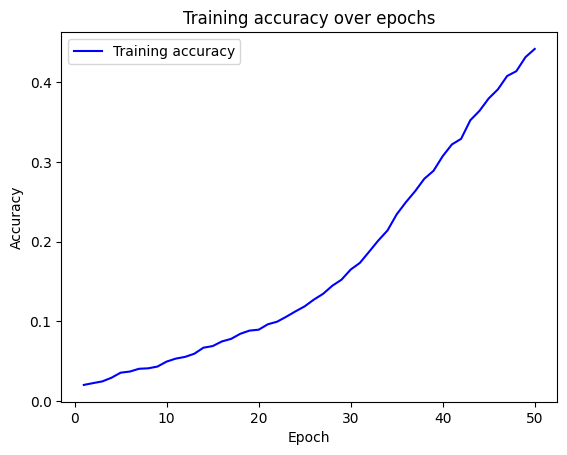

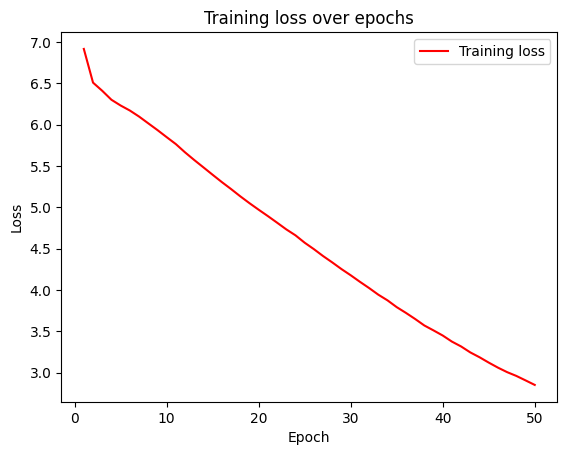

In [23]:
import matplotlib.pyplot as plt

# Per-epoch metrics recorded during training
acc = history.history['accuracy']
loss = history.history['loss']
epochs = range(1, len(acc) + 1)

# Training accuracy
plt.figure()
plt.plot(epochs, acc, 'b-', label='Training accuracy')
plt.title('Training accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Training loss
plt.figure()
plt.plot(epochs, loss, 'r-', label='Training loss')
plt.title('Training loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Generate text with the model based on a seed text

Now you will create two variables :

- seed_text = 'Write the text you want the model to use as a starting point to generate the next words'
- next_words = number_of_words_you_want_the_model_to_generate

Please change number_of_words_you_want_the_model_to_generate by an actual integer.

In [24]:
seed_text = "Shall I compare thee to a summer's day"
next_words = 50

Now create a loop that runs based on the next_words variable and generates new text based on your seed_text input string. Print the full text with the generated text at the end.

This time you dont get detailed instructions.

Have fun!

In [26]:
for _ in range(next_words):
    # Convert the current text to integers
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    # Pad to the length the model expects (max_sequence_len - 1)
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

    # Predict a probability distribution over the vocabulary and take the most likely word index
    predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

    # Map the index back to a word
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break

    # Append the word to the running text
    seed_text += " " + output_word

print(seed_text)

Shall I compare thee to a summer's day are purging ' stand transferr'd stand ' ' ' bold fill all change mortal ' 'will' own ' say me me so lie wrinkles view you bring men lie forth lie of thee love green them night of single too ill hell old forth told to showers all all my love doth praise fled free groan thee last so ' lie mortal lie forth lie of thee more green me lack happy alone blind glory ' be hide me so me ' ' view none ' dost you prove make me change mortal ' fill mortal best say store more


Experiment with at least 3 different seed_text strings and see what happens!

In [27]:
index_word = tokenizer.index_word  # reverse lookup, built once

def generate_text(seed_text, next_words=50, temperature=None):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text.lower()])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')
        probs = model.predict(token_list, verbose=0)[0]

        if temperature is None:
            predicted = np.argmax(probs)  # greedy
        else:
            logits = np.log(probs + 1e-9) / temperature
            p = np.exp(logits) / np.sum(np.exp(logits))
            predicted = np.random.choice(len(p), p=p)

        seed_text += " " + index_word.get(predicted, "")
    return seed_text

seeds = [
    "Shall I compare thee to a summer's day",
    "When I do count the clock that tells the time",
    "Love is not love which alters when it alteration finds",
    "My mistress eyes are nothing like the sun",
]

for seed in seeds:
    print(f"SEED: {seed}")
    print(generate_text(seed, next_words=40))
    print("-" * 60)

SEED: Shall I compare thee to a summer's day
Shall I compare thee to a summer's day are purging ' stand transferr'd stand ' ' ' bold fill all change mortal ' 'will' own ' say me me so lie wrinkles view you bring men lie forth lie of thee love green them night of single too
------------------------------------------------------------
SEED: When I do count the clock that tells the time
When I do count the clock that tells the time exchanged ' say thence 'will' to ' be stand stand ' stand fortify say me change mortal ' hide time mortal lie grew me green you ease go pleasure show me loss of thee hide thee green mortal near slain
------------------------------------------------------------
SEED: Love is not love which alters when it alteration finds
Love is not love which alters when it alteration finds you told all heaven more pain write of me you long prove life mortal ' say so me blind blind lie that so ' ' grew the part life now more age ' view ' grew life me so '
----------------------